In [1]:
%load_ext autoreload
%autoreload 2

# LightGBM Directional Prediction Signal

This notebook walks through:
1. **Training** -- Load data, extract features, create labels, walk-forward validate, tune hyperparameters, train final model
2. **Backtesting** -- Run the trained signal through `SimpleOMS` + `MBPSimulatedExchange` and inspect results

## Configuration

In [2]:
import datetime
import numpy as np
import pandas as pd

from gnomepy.data.types import SchemaType
from gnomepy.data.cached_client import CachedMarketDataClient
from gnomepy.registry.api import RegistryClient

# -- Dates ----------------------------------------------------------------
TRAIN_START = datetime.datetime(2026, 1, 15, 12, 0)
TRAIN_END   = datetime.datetime(2026, 1, 18, 12, 0)

BACKTEST_START = datetime.datetime(2026, 1, 18, 12, 0)
BACKTEST_END   = datetime.datetime(2026, 1, 19, 0, 0)

SCHEMA_TYPE = SchemaType.MBP_10
LISTING_ID = 1

# -- Training parameters ---------------------------------------------------
HORIZON = 300          # ticks to look ahead for label
THRESHOLD_BPS = 0.5   # dead-zone around zero
TRAIN_WINDOW = 50000  # rows per training fold
VAL_WINDOW   = 10000  # rows per validation fold

# -- Signal parameters -----------------------------------------------------
NOTIONAL = 100_000
ENTRY_THRESHOLD = 0.8
TRANSACTION_COST_BPS = 2.0
MAX_INVENTORY = 5.0
EXIT_HOLD_TICKS = 10000
STOP_LOSS_BPS = 5.0
TAKE_PROFIT_BPS = 10.0

# -- Clients ---------------------------------------------------------------
market_data_client = CachedMarketDataClient(
    bucket="gnome-market-data-dev",
    aws_profile_name="AWSAdministratorAccess-443370708724",
)
registry_client = RegistryClient(
    api_key="9WPV7CfeqXa578yVYlxdG3kCPFzACr7YaMU0UVma",
)

# Load listing
listing = registry_client.get_listing(listing_id=LISTING_ID)[0]
print(f"Listing: {listing}")

Listing: Listing(listing_id=1, security_id=1, exchange_id=1, exchange_security_id='undefined', exchange_security_symbol='BTC', date_modified='2025-12-23T18:11:06.557Z', date_created='2025-12-23T18:11:06.557Z')


---
## Part 1 -- Training

### 1.1 Load data & extract features

In [3]:
from gnomepy.research.signals.lgbm_directional.trainer import LGBMTrainer
from gnomepy.research.signals.lgbm_directional.registry import ModelRegistry
from gnomepy.research.signals.lgbm_directional.features import FEATURE_NAMES

trainer = LGBMTrainer(
    listing_id=LISTING_ID,
    start_datetime=TRAIN_START,
    end_datetime=TRAIN_END,
    schema_type=SCHEMA_TYPE,
    horizon=HORIZON,
    threshold_bps=THRESHOLD_BPS,
    market_data_client=market_data_client,
    registry_client=registry_client,
)

X, y = trainer.prepare()
print(f"\nFeatures shape: {X.shape}")
print(f"Label balance: {y.value_counts().to_dict()}")
display(X.describe())

Loading data for listing 1 ...
  Loaded 861456 rows
  860957 usable samples, class split: up=0.349 neutral=0.301 down=0.349

Features shape: (860957, 44)
Label balance: {0.0: 300776, 1.0: 300606, 0.5: 259575}


,tob_imbalance,depth3_imbalance,depth5_imbalance,depth10_imbalance,count_imbalance,price_weighted_imbalance,total_bid_depth,total_ask_depth,depth_ratio,depth_diff,...,total_bid_depth_z,total_ask_depth_z,spread_bps_z,depth_diff_z,bid_withdrawal_5,ask_withdrawal_5,withdrawal_imbalance_5,bid_withdrawal_20,ask_withdrawal_20,withdrawal_imbalance_20
count,860957.000000,860957.000000,860957.000000,860957.000000,8.609570e+05,860957.000000,860957.000000,860957.000000,860957.000000,860957.000000,...,860957.000000,860957.000000,860957.000000,860957.000000,860957.000000,860957.000000,860957.000000,860957.000000,860957.000000,860957.000000
mean,0.036618,0.042915,0.046184,0.057817,6.076928e+07,0.057797,21.238856,17.513715,0.528909,3.725141,...,0.102825,0.084266,0.044597,0.021121,5.140962,3.743699,0.063270,20.563797,14.974852,0.083865
std,0.803308,0.795859,0.785552,0.739740,1.072202e+08,0.739741,25.955853,23.652958,0.369870,40.475004,...,1.431118,1.433196,1.581935,1.385236,14.400506,10.855429,0.625778,33.573453,25.131773,0.636733
min,-1.000000,-0.999994,-0.999988,-0.999973,0.000000e+00,-0.999973,0.001300,0.001300,0.000014,-431.139680,...,-14.071425,-14.071425,-179.506768,-14.071431,0.000000,0.000000,-1.000000,0.000000,0.000000,-1.000000
25%,-0.850300,-0.825825,-0.800839,-0.706807,7.187500e-01,-0.706825,3.933310,2.660900,0.146597,-17.168880,...,-0.795023,-0.809941,-0.324948,-0.847648,0.000000,0.000000,-0.279316,1.221890,0.820600,-0.427440
50%,0.101767,0.112621,0.116964,0.123015,9.812207e-01,0.122968,13.820840,9.749550,0.561507,2.830690,...,-0.214986,-0.248114,-0.122964,-0.008544,0.630470,0.324000,0.000000,8.914170,5.767900,0.000000
75%,0.906321,0.897988,0.883707,0.817527,1.022611e+08,0.817516,28.203730,22.228450,0.908764,24.114920,...,0.823710,0.814992,0.000000,0.858089,4.216140,2.927990,0.610367,22.560500,17.113580,0.682236
max,1.000000,0.999995,0.999991,0.999972,1.431656e+09,0.999972,258.713270,431.233850,0.999986,257.701270,...,14.071425,14.071425,370.243242,14.071426,557.392970,414.056750,1.000000,827.902200,755.176760,1.000000


In [33]:
mid = trainer._raw_df["midPrice"].values
ret = (mid[20:] - mid[:-20]) / mid[:-20]

for t in [0.05, 0.1, 0.25, 0.5, 1.0, 2.0]:
    thresh = t / 1e4
    up = (ret > thresh).mean()
    down = (ret < -thresh).mean()
    neutral = 1 - up - down
    print(f"  threshold_bps={t:4.1f}  up={up:.3f}  neutral={neutral:.3f}  down={down:.3f}")

mid = trainer._raw_df["midPrice"].values

for h in [20, 50, 100, 200, 300, 500]:
    ret = (mid[h:] - mid[:-h]) / mid[:-h]
    std_bps = np.std(ret) * 1e4
    above_5 = (np.abs(ret) > 5e-4).mean()
    print(f"  horizon={h:4d}  std={std_bps:.2f} bps  |ret|>5bps: {above_5:.1%}")

mid = trainer._raw_df["midPrice"].values
for h in [20, 50, 100, 200, 300]:
    ret = (mid[h:] - mid[:-h]) / mid[:-h]
    for t in [0.25, 0.5, 1.0, 2.0]:
        thresh = t / 1e4
        up = (ret > thresh).mean()
        down = (ret < -thresh).mean()
        neutral = 1 - up - down
        if 0.25 < up < 0.45 and 0.25 < down < 0.45:
            print(f"  *** horizon={h:4d} threshold_bps={t:.2f}  up={up:.3f} neutral={neutral:.3f} down={down:.3f}")

  threshold_bps= 0.1  up=0.169  neutral=0.667  down=0.164
  threshold_bps= 0.1  up=0.166  neutral=0.672  down=0.161
  threshold_bps= 0.2  up=0.128  neutral=0.752  down=0.121
  threshold_bps= 0.5  up=0.100  neutral=0.804  down=0.097
  threshold_bps= 1.0  up=0.048  neutral=0.902  down=0.050
  threshold_bps= 2.0  up=0.014  neutral=0.971  down=0.016
  horizon=  20  std=1.93 bps  |ret|>5bps: 0.8%
  horizon=  50  std=3.07 bps  |ret|>5bps: 2.1%
  horizon= 100  std=4.38 bps  |ret|>5bps: 4.6%
  horizon= 200  std=6.20 bps  |ret|>5bps: 12.2%
  horizon= 300  std=7.47 bps  |ret|>5bps: 19.3%
  horizon= 500  std=9.27 bps  |ret|>5bps: 29.3%
  *** horizon= 100 threshold_bps=0.25  up=0.329 neutral=0.342 down=0.329
  *** horizon= 100 threshold_bps=0.50  up=0.296 neutral=0.408 down=0.296
  *** horizon= 200 threshold_bps=0.25  up=0.403 neutral=0.190 down=0.406
  *** horizon= 200 threshold_bps=0.50  up=0.376 neutral=0.245 down=0.379
  *** horizon= 200 threshold_bps=1.00  up=0.307 neutral=0.385 down=0.309
  

### 1.2 Quick EDA

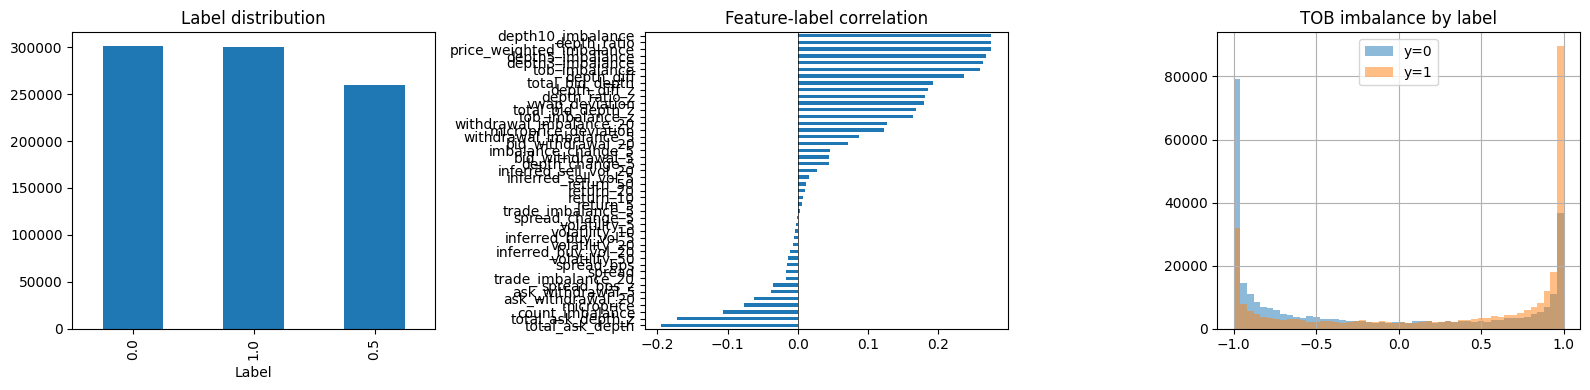

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Label distribution
y.value_counts().plot.bar(ax=axes[0], title="Label distribution")
axes[0].set_xlabel("Label")

# Feature correlation with label
corrs = X.corrwith(y).sort_values()
corrs.plot.barh(ax=axes[1], title="Feature-label correlation")
axes[1].axvline(0, color="k", lw=0.5)

# TOB imbalance distribution by label
for label in [0, 1]:
    X.loc[y == label, "tob_imbalance"].hist(
        ax=axes[2], bins=50, alpha=0.5, label=f"y={int(label)}"
    )
axes[2].set_title("TOB imbalance by label")
axes[2].legend()

plt.tight_layout()
plt.show()

### 1.3 Walk-forward validation (default params)

In [9]:
default_params = {
    "num_leaves": 31,
    "max_depth": 6,
    "learning_rate": 0.05,
    "min_child_samples": 100,
    "feature_fraction": 0.8,
}

fold_results = trainer.walk_forward_validate(
    params=default_params,
    train_window=TRAIN_WINDOW,
    val_window=VAL_WINDOW,
)

report = trainer.report(fold_results)

  860957 usable samples, class split: up=0.349 neutral=0.301 down=0.349

=== Walk-Forward Report ===

Fold 0: {'auc': 0.6761053510005466, 'accuracy': 0.5924133624726818, 'precision': 0.5836203597397627, 'recall': 0.8751793400286944, 'f1': 0.7002640339800252, 'log_loss': 0.6637560616205991, 'neutral_mae': 0.1995514657544208, 'neutral_pct': 0.3594}
Fold 1: {'auc': 0.7637579904578081, 'accuracy': 0.5836757829105852, 'precision': 0.5836757829105852, 'recall': 1.0, 'f1': 0.7371152469577666, 'log_loss': 0.6478957034191412, 'neutral_mae': 0.10104499802444794, 'neutral_pct': 0.2943}
Fold 2: {'auc': 0.7589016091263385, 'accuracy': 0.4244329051653457, 'precision': 0.3369981675828752, 'recall': 0.8971175166297117, 'f1': 0.489949140227658, 'log_loss': 0.7892998925358966, 'neutral_mae': 0.20547709984403378, 'neutral_pct': 0.2682}
Fold 3: {'auc': 0.7091021210784816, 'accuracy': 0.6489985344406448, 'precision': 0.6483185840707965, 'recall': 0.805054945054945, 'f1': 0.7182352941176471, 'log_loss': 0.6

In [ ]:
# Visualise per-fold metrics
metrics_df = pd.DataFrame([fr.metrics for fr in fold_results])
metrics_df.index.name = "fold"

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for i, col in enumerate(["auc", "accuracy", "log_loss"]):
    metrics_df[col].plot(ax=axes[i], marker="o", title=col)
    axes[i].axhline(metrics_df[col].mean(), ls="--", color="grey", lw=0.8)
plt.tight_layout()
plt.show()
display(metrics_df)

### 1.4 Hyperparameter tuning

In [ ]:
from gnomepy.research.signals.lgbm_directional.trainer import DEFAULT_PARAM_GRID

tuning_result = trainer.tune_hyperparameters(
    param_grid=DEFAULT_PARAM_GRID,
    train_window=TRAIN_WINDOW,
    val_window=VAL_WINDOW,
    n_random=20,   # random search over 20 combos (set to None for full grid)
    metric="auc",
)

print(f"\nBest params: {tuning_result.best_params}")
display(pd.DataFrame(tuning_result.all_results).head(10))

### 1.5 Train final model & register

In [14]:
registry = ModelRegistry(base_dir="./models")

model = trainer.train(
    params=default_params or tuning_result.best_params,
    register=True,
    registry=registry,
)

print(f"\nRegistered versions:")
display(registry.compare(LISTING_ID))

  860957 usable samples, class split: up=0.349 neutral=0.301 down=0.349
  860957 usable samples, class split: up=0.349 neutral=0.301 down=0.349
Registered as v6

Registered versions:


,created_at,mean_auc,mean_accuracy
version,,,
v1,2026-02-19T23:53:58.215545+00:00,0.967814,0.909924
v2,2026-02-21T03:14:23.031900+00:00,0.760163,0.469505
v3,2026-02-21T04:28:35.657479+00:00,0.652486,0.595910
v4,2026-02-21T16:35:04.167711+00:00,0.699804,0.587279
v5,2026-02-21T17:06:46.657286+00:00,0.699804,0.587279
v6,2026-02-21T17:15:46.970049+00:00,0.697010,0.587927


### 1.6 Feature importance

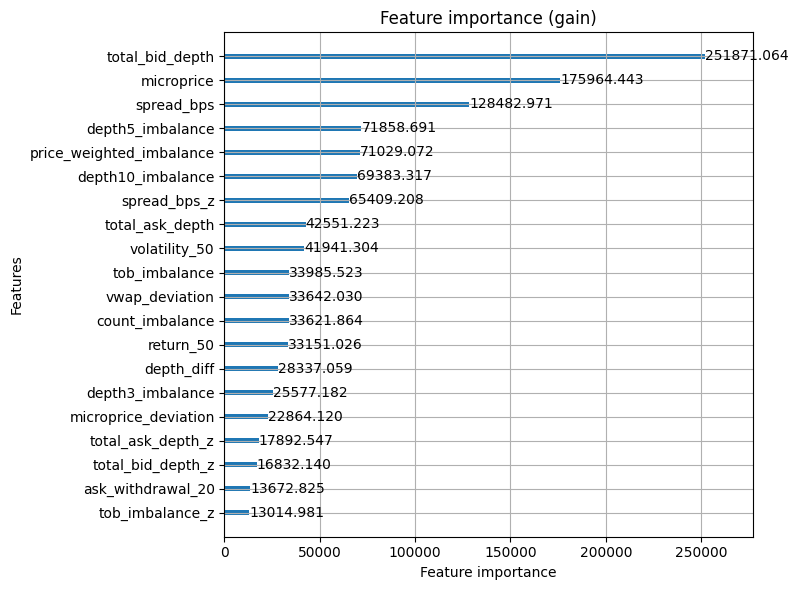

In [15]:
import lightgbm as lgb

fig, ax = plt.subplots(figsize=(8, 6))
lgb.plot_importance(model, ax=ax, importance_type="gain", max_num_features=20)
ax.set_title("Feature importance (gain)")
plt.tight_layout()
plt.show()

### 1.7 Registry round-trip verification

In [16]:
loaded_model, meta = registry.load_latest(LISTING_ID)

# Verify predictions match on the last chunk of training data
X_check = X.tail(100)
preds_original = model.predict(X_check)
preds_loaded   = loaded_model.predict(X_check)

assert np.allclose(preds_original, preds_loaded), "Predictions diverged after round-trip!"
print("Registry round-trip OK -- predictions match")
print(f"Model version: {meta['version']}")
print(f"Walk-forward mean AUC: {meta['walk_forward_metrics'].get('mean_auc', 'N/A')}")
print(f"Feature Count: {len(meta['feature_names'])}")

meta

Registry round-trip OK -- predictions match
Model version: v6
Walk-forward mean AUC: 0.6970096733976645
Feature Count: 44


{'feature_names': ['tob_imbalance',
  'depth3_imbalance',
  'depth5_imbalance',
  'depth10_imbalance',
  'count_imbalance',
  'price_weighted_imbalance',
  'total_bid_depth',
  'total_ask_depth',
  'depth_ratio',
  'depth_diff',
  'spread',
  'spread_bps',
  'microprice',
  'microprice_deviation',
  'return_5',
  'return_10',
  'return_20',
  'return_50',
  'volatility_5',
  'volatility_10',
  'volatility_20',
  'volatility_50',
  'imbalance_change_5',
  'spread_change_5',
  'depth_change_5',
  'vwap_deviation',
  'inferred_buy_vol_5',
  'inferred_buy_vol_20',
  'inferred_sell_vol_5',
  'inferred_sell_vol_20',
  'trade_imbalance_5',
  'trade_imbalance_20',
  'tob_imbalance_z',
  'depth_ratio_z',
  'total_bid_depth_z',
  'total_ask_depth_z',
  'spread_bps_z',
  'depth_diff_z',
  'bid_withdrawal_5',
  'ask_withdrawal_5',
  'withdrawal_imbalance_5',
  'bid_withdrawal_20',
  'ask_withdrawal_20',
  'withdrawal_imbalance_20'],
 'horizon': 300,
 'threshold_bps': 1.0,
 'training_start': '2026-

---
## Part 2 -- Backtesting

### 2.1 Set up exchange, signal, OMS, and strategy

In [25]:
from gnomepy import Strategy, LatencyModel, SchemaBase, Order, OrderExecutionReport
from gnomepy.research.oms import SimpleOMS
from gnomepy.research.signals.lgbm_directional import LGBMDirectionalSignal
from gnomepy.research.signals.lgbm_directional.signal import LGBMDirectionalRecorder
from gnomepy.backtest import (
    Backtest,
    MBPSimulatedExchange,
    StaticLatency,
    RiskAverseQueueModel,
    StaticFeeModel,
)
from gnomepy.backtest.recorder import Recorder

print("=== LightGBM Directional Signal Backtest ===")

# -- Latency ---------------------------------------------------------------
STRATEGY_LATENCY = StaticLatency(500_000)             # 500 us
NETWORK_LATENCY = StaticLatency(100_000_000)          # 100 ms
ORDER_PROCESSING_LATENCY = StaticLatency(200_000_000) # 200 ms

# -- Exchange ---------------------------------------------------------------
exchanges = {
    listing.exchange_id: {
        listing.security_id: MBPSimulatedExchange(
            fee_model=StaticFeeModel(taker_fee=0.0003, maker_fee=0.0001),
            network_latency=NETWORK_LATENCY,
            order_processing_latency=ORDER_PROCESSING_LATENCY,
            queue_model=RiskAverseQueueModel(),
        )
    }
}

# -- Signal recorder -------------------------------------------------------
signal_recorder = LGBMDirectionalRecorder(listing_ids=[LISTING_ID])

# -- Signal ----------------------------------------------------------------
signal = LGBMDirectionalSignal(
    listing=listing,
    registry=registry,
    trade_frequency=1,
    entry_threshold=ENTRY_THRESHOLD,
    transaction_cost_bps=TRANSACTION_COST_BPS,
    max_inventory=MAX_INVENTORY,
    exit_hold_ticks=EXIT_HOLD_TICKS,
    stop_loss_bps=STOP_LOSS_BPS,
    take_profit_bps=TAKE_PROFIT_BPS,
    recorder=signal_recorder,
)

# -- OMS (market orders) ---------------------------------------------------
oms = SimpleOMS(
    signals=[signal],
    notional=NOTIONAL,
)

# -- Strategy wrapper ------------------------------------------------------
class OMSStrategy(Strategy):
    def __init__(self, processing_latency: LatencyModel, oms):
        super().__init__(processing_latency)
        self.oms = oms

    def on_market_data(self, timestamp: int, data: SchemaBase, recorder: Recorder | None = None) -> list[Order]:
        return self.oms.on_market_update(timestamp, data, recorder)

    def on_execution_report(self, timestamp: int, execution_report: OrderExecutionReport, recorder: Recorder | None = None):
        self.oms.on_execution_report(timestamp, execution_report, recorder)

strategy = OMSStrategy(processing_latency=STRATEGY_LATENCY, oms=oms)
print(f"Signal loaded with model version: latest")
print(f"Backtest period: {BACKTEST_START} to {BACKTEST_END}")

=== LightGBM Directional Signal Backtest ===
Signal loaded with model version: latest
Backtest period: 2026-01-18 12:00:00 to 2026-01-19 00:00:00


### 2.2 Run backtest

In [26]:
backtest = Backtest(
    start_datetime=BACKTEST_START,
    end_datetime=BACKTEST_END,
    listing_ids=[LISTING_ID],
    schema_type=SCHEMA_TYPE,
    strategy=strategy,
    exchanges=exchanges,
    market_data_client=market_data_client,
    registry_client=registry_client,
)

print("Preparing data...")
backtest.prepare_data()

Preparing data...


In [27]:
print("Executing backtest...")
backtest.fully_execute()
print("Done.")

Executing backtest...
Done.


### 2.3 Results overview

In [28]:
print("=== OMS State ===")
print(f"Positions: {oms.positions}")
print(f"Orders submitted: {len(oms.order_log)}")

print(f"\n=== Recorder Summary ===")
print(backtest.recorder.get_summary_stats())

=== OMS State ===
Positions: {1: 0.6479596740590173}
Orders submitted: 198

=== Recorder Summary ===
{'total_records': np.int64(234103), 'market_buffer_usage': {1: np.float64(0.5852575)}, 'intent_buffer_usage': {1: np.float64(0.0)}, 'schema_type': 'mbp-10', 'assets': {1: {'market_record_count': 234103, 'market_timestamp_range': (1768758780480709976, 1768784400190966626), 'market_price_range': (91881.5, 95534.5)}}}


### 2.4 PnL analysis

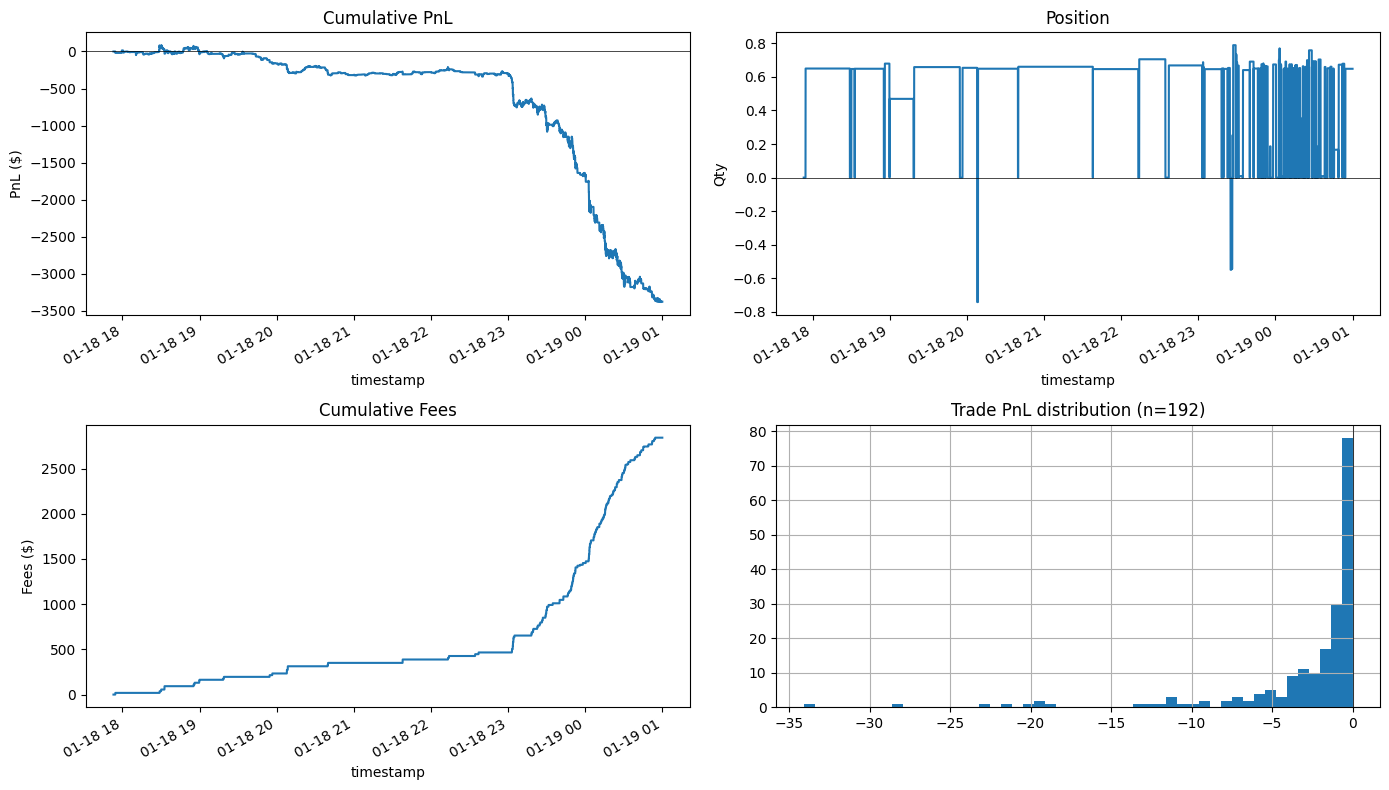

,pnl,fee,trade_pnl,holding_pnl
total,-3380.186536,2841.148923,-576.691282,37.653669


In [29]:
record_df = backtest.recorder.get_record(LISTING_ID).df

# Cumulative PnL
if "pnl" in record_df.columns:
    fig, axes = plt.subplots(2, 2, figsize=(14, 8))

    record_df["pnl"].cumsum().plot(ax=axes[0, 0], title="Cumulative PnL")
    axes[0, 0].set_ylabel("PnL ($)")
    axes[0, 0].axhline(0, color="k", lw=0.5)

    # Position over time
    record_df["quantity"].plot(ax=axes[0, 1], title="Position")
    axes[0, 1].set_ylabel("Qty")
    axes[0, 1].axhline(0, color="k", lw=0.5)

    # Fees
    if "fee" in record_df.columns:
        record_df["fee"].cumsum().plot(ax=axes[1, 0], title="Cumulative Fees")
        axes[1, 0].set_ylabel("Fees ($)")

    # Trade PnL histogram
    trades = record_df.loc[record_df["trade_pnl"].abs() > 0, "trade_pnl"] if "trade_pnl" in record_df.columns else pd.Series(dtype=float)
    if len(trades) > 0:
        trades.hist(ax=axes[1, 1], bins=50)
        axes[1, 1].set_title(f"Trade PnL distribution (n={len(trades)})")
        axes[1, 1].axvline(0, color="k", lw=0.5)

    plt.tight_layout()
    plt.show()

    # Summary
    pnl_cols = [c for c in ["pnl", "fee", "trade_pnl", "holding_pnl"] if c in record_df.columns]
    display(record_df[pnl_cols].sum().to_frame("total").T)
else:
    print("No PnL column found in record.")

### 2.5 Inspect trades

In [30]:
# Show fills (event == 2 is a fill in the recorder)
fills = record_df[record_df["event"] == 2] if "event" in record_df.columns else record_df[record_df["trade_quantity"].abs() > 0]
print(f"Total fills: {len(fills)}")
display(fills)

Total fills: 192


,event,price,trade_price,quantity,fee,holding_pnl,trade_pnl,pnl_wo_fee,pnl,nmv
timestamp,,,,,,,,,,
2026-01-18 17:54:23.781257809,2.0,95210.5,95211.000000,0.649530,18.552710,0.00000,-0.324765,-0.324765,-18.877475,61842.042148
2026-01-18 18:28:51.191416648,2.0,95367.0,95366.000000,0.000000,18.582913,0.00000,-0.649530,-0.649530,-19.232443,0.000000
2026-01-18 18:30:02.481232736,2.0,95372.5,95377.075272,0.646962,18.511599,0.00000,-2.960027,-2.960027,-21.471626,61702.371256
2026-01-18 18:32:39.191413112,2.0,95319.5,95319.000000,0.000000,18.500328,0.00000,-0.323481,-0.323481,-18.823809,0.000000
2026-01-18 18:32:40.791427541,2.0,95319.5,95320.000000,0.648236,18.536944,0.00000,-0.324118,-0.324118,-18.861062,61789.490694
...,...,...,...,...,...,...,...,...,...,...
2026-01-19 00:49:11.183401515,2.0,92749.5,92751.901734,0.672282,18.706629,0.00000,-1.614643,-1.614643,-20.321272,62353.815947
2026-01-19 00:51:57.181209919,2.0,92685.5,92682.000000,0.000000,18.692531,0.00000,-2.352987,-2.352987,-21.045518,0.000000
2026-01-19 00:52:10.881245951,2.0,92700.5,92701.000000,0.678182,18.860455,0.00000,-0.339091,-0.339091,-19.199546,62867.844290


### 2.6 Strategy statistics

,start_timestamp,end_timestamp,total_pnl,total_fees,sr,max_dd,volatility,win_rate,return_on_fees,trade_volume,num_trades
0,2026-01-18 17:53:00.480709976,2026-01-19 01:00:00.190966626,-3380.186536,2841.148923,-0.024252,113.448665,1.695524,2.901389,-1.189725,101.102158,192.0


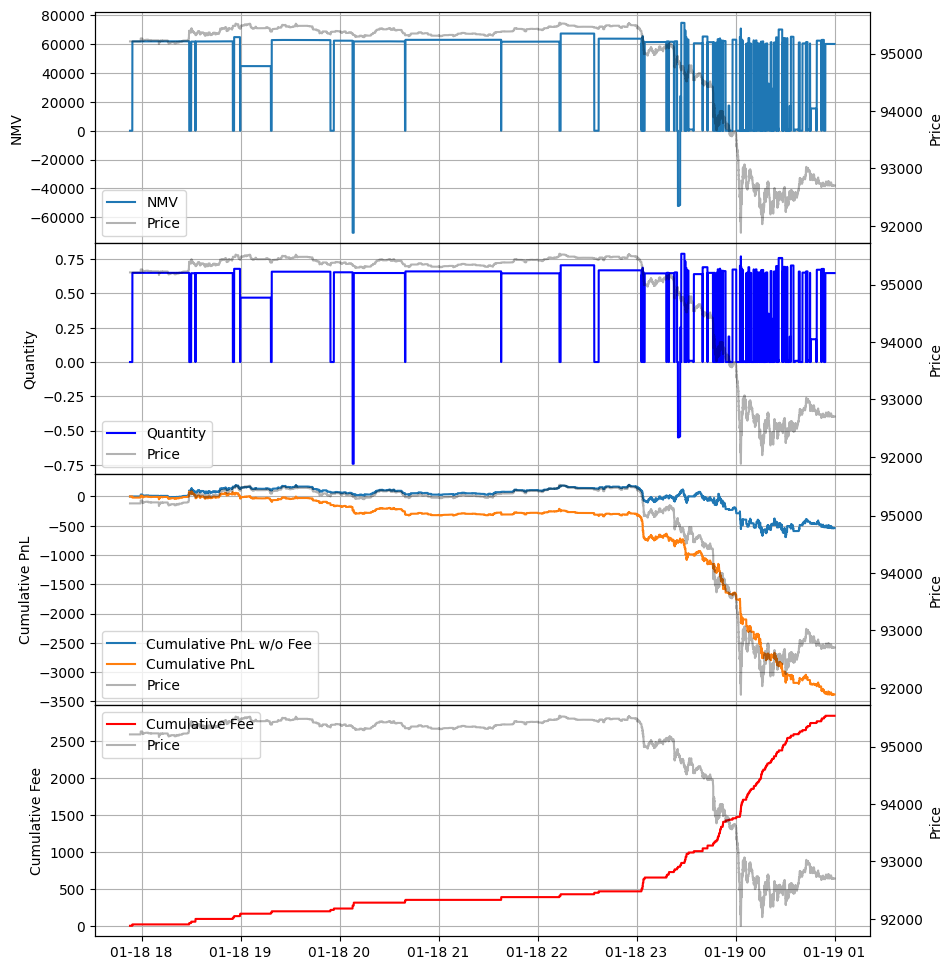

In [31]:
listing_stats = backtest.recorder.get_record(LISTING_ID).stats()
display(listing_stats.summary())
listing_stats.plot()

Signal recorder: 233911 rows
Columns: ['mid_price', 'prob_up', 'inventory', 'pnl_bps', 'ticks_in_position', 'entry_price']


,mid_price,prob_up,inventory,pnl_bps,ticks_in_position,entry_price
count,233911.000000,232119.000000,233911.000000,154992.000000,233911.000000,154992.000000
mean,93847.947670,0.641145,0.386893,3.423001,1305.370290,94161.921060
std,1244.931608,0.126897,0.323164,4.638310,1916.310136,1265.168092
min,91881.500000,0.118995,-0.741380,-13.566028,0.000000,91942.000000
25%,92641.500000,0.550634,0.000000,0.000000,0.000000,92728.500000
50%,93744.500000,0.653697,0.646141,2.932505,468.000000,94718.500000
75%,95308.500000,0.739587,0.658081,6.496943,1688.000000,95322.500000
max,95534.500000,0.952610,0.788600,23.158467,10000.000000,95502.500000


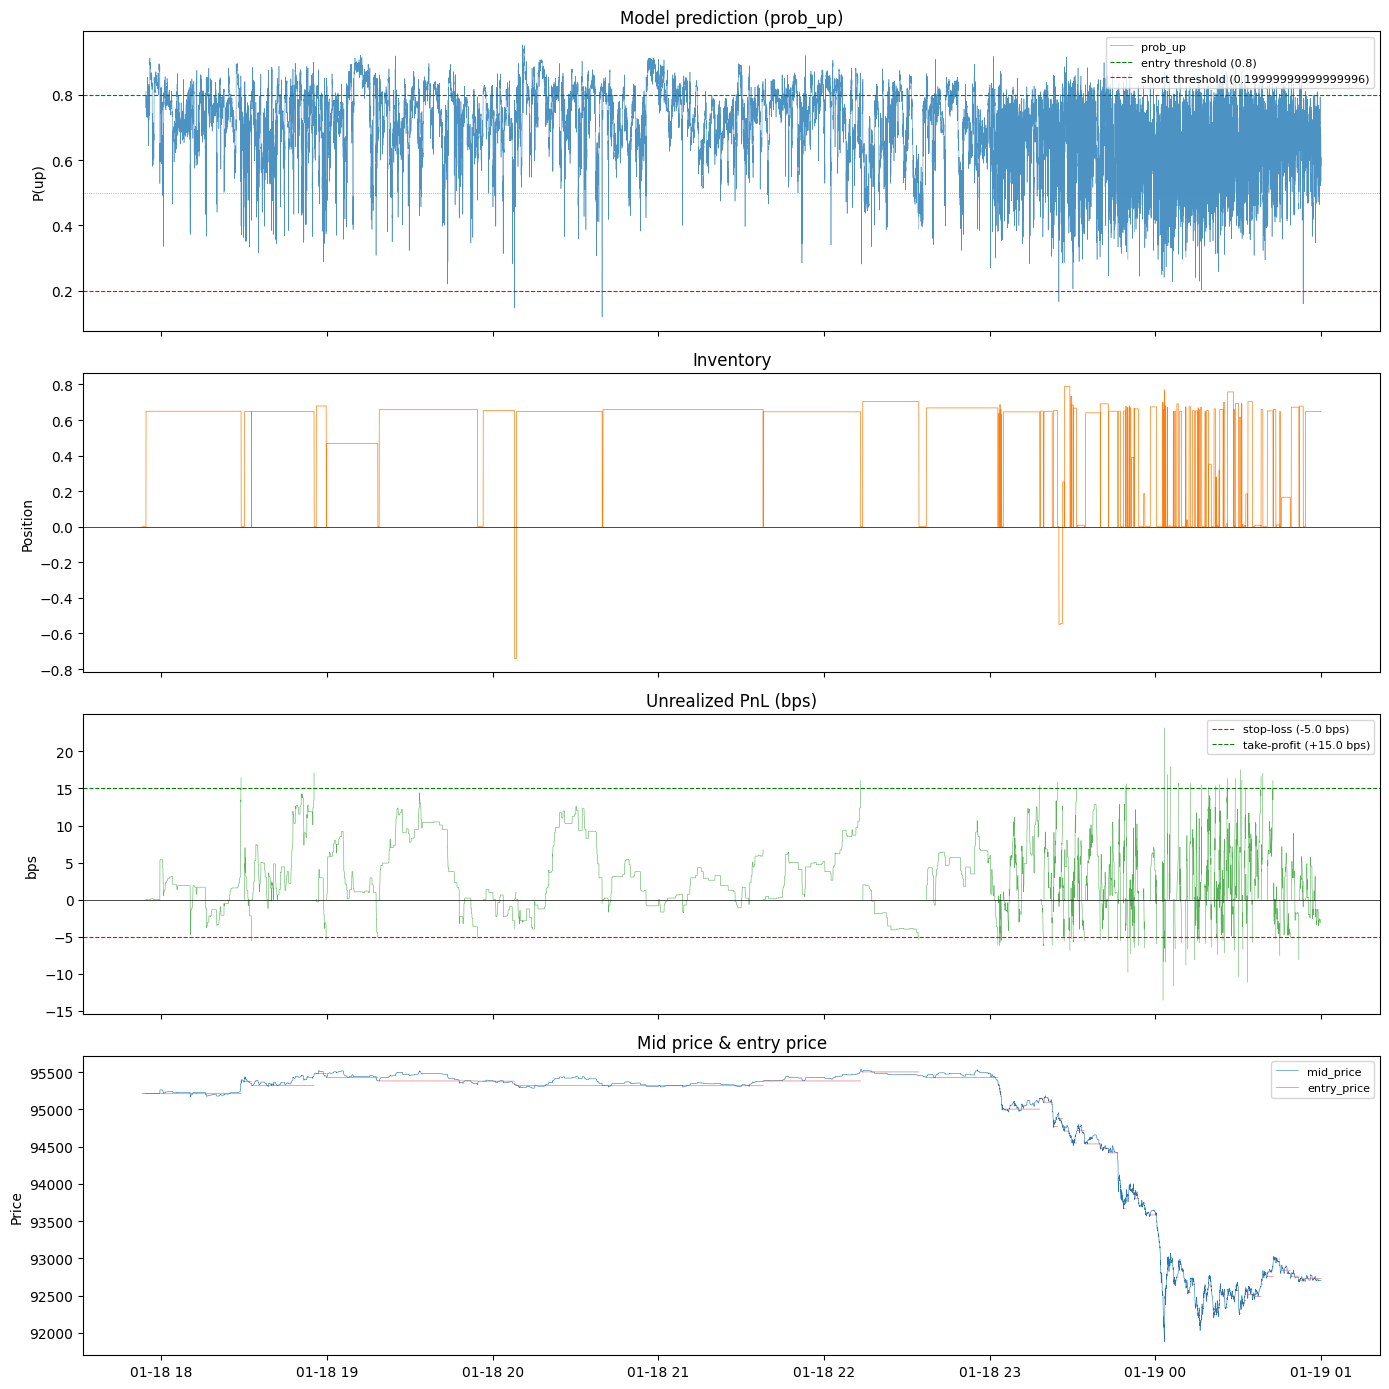

In [32]:
### 2.7 Signal recorder diagnostics

sig_record = signal_recorder.get_record(LISTING_ID)
sig_df = sig_record.df
print(f"Signal recorder: {len(sig_df)} rows")
print(f"Columns: {list(sig_df.columns)}")
display(sig_df.describe())

fig, axes = plt.subplots(4, 1, figsize=(14, 14), sharex=True)

# 1. prob_up over time with entry threshold lines
axes[0].plot(sig_df.index, sig_df["prob_up"], linewidth=0.4, alpha=0.8, label="prob_up")
axes[0].axhline(ENTRY_THRESHOLD, color="green", ls="--", lw=0.8, label=f"entry threshold ({ENTRY_THRESHOLD})")
axes[0].axhline(1 - ENTRY_THRESHOLD, color="red", ls="--", lw=0.8, label=f"short threshold ({1 - ENTRY_THRESHOLD})")
axes[0].axhline(0.5, color="grey", ls=":", lw=0.5)
axes[0].set_ylabel("P(up)")
axes[0].set_title("Model prediction (prob_up)")
axes[0].legend(loc="upper right", fontsize=8)

# 2. Inventory over time
axes[1].plot(sig_df.index, sig_df["inventory"], linewidth=0.5, color="tab:orange")
axes[1].axhline(0, color="k", lw=0.5)
axes[1].set_ylabel("Position")
axes[1].set_title("Inventory")

# 3. Unrealized PnL in bps with stop-loss / take-profit lines
axes[2].plot(sig_df.index, sig_df["pnl_bps"], linewidth=0.4, color="tab:green", alpha=0.8)
axes[2].axhline(-STOP_LOSS_BPS, color="red", ls="--", lw=0.8, label=f"stop-loss (-{STOP_LOSS_BPS} bps)")
axes[2].axhline(TAKE_PROFIT_BPS, color="green", ls="--", lw=0.8, label=f"take-profit (+{TAKE_PROFIT_BPS} bps)")
axes[2].axhline(0, color="k", lw=0.5)
axes[2].set_ylabel("bps")
axes[2].set_title("Unrealized PnL (bps)")
axes[2].legend(loc="upper right", fontsize=8)

# 4. Mid price with entry price overlay
axes[3].plot(sig_df.index, sig_df["mid_price"], linewidth=0.4, color="tab:blue", label="mid_price")
axes[3].plot(sig_df.index, sig_df["entry_price"], linewidth=0.5, color="tab:red", alpha=0.6, label="entry_price")
axes[3].set_ylabel("Price")
axes[3].set_title("Mid price & entry price")
axes[3].legend(loc="upper right", fontsize=8)

plt.tight_layout()
plt.show()